# Introduction

This notebook builds a hybrid forecasting model for half-hourly electricity demand in NSW.
We combine deterministic trend modeling (Ridge + Fourier terms) with gradient boosting (LightGBM) on residuals.
The final hybrid model achieves:

* Validation R²: 0.93
* Test R²: 0.85

SHAP analysis reveals lag features dominate short-term predictive power, while seasonal Fourier components capture macro structure.

# Imports

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMRegressor
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess

import shap
shap.initjs()

# Data Overview

In [2]:
path = "/kaggle/input/nsw-australia-electricity-demand-2018-2023/"
all_files = glob.glob(os.path.join(path, "*.csv"))
df_raw = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
print("Raw rows:", len(df_raw))
df_raw.head()

Raw rows: 248592


,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,NSW1,2021/08/01 00:30:00,7488.85,70.92,TRADE
1,NSW1,2021/08/01 01:00:00,7270.30,56.55,TRADE
2,NSW1,2021/08/01 01:30:00,7045.65,55.57,TRADE
3,NSW1,2021/08/01 02:00:00,6813.62,48.83,TRADE
4,NSW1,2021/08/01 02:30:00,6557.80,37.00,TRADE


In [3]:
print("Null Values:\n",df_raw.isnull().sum()/len(df_raw))

Null Values:
 REGION            0.0
SETTLEMENTDATE    0.0
TOTALDEMAND       0.0
RRP               0.0
PERIODTYPE        0.0
dtype: float64


In [4]:
df_raw.describe()

,TOTALDEMAND,RRP
count,248592.000000,248592.000000
mean,7609.351612,128.619204
std,1270.924160,289.366592
min,3957.320000,-1000.000000
25%,6682.177500,59.950000
50%,7470.850000,89.010000
75%,8324.510000,144.410000
max,13700.900000,15500.000000


# Feature Engineering

* Calendar features capture periodic behavior
* Lag features encode autoregressive structure
* Rolling windows smooth short-term volatility
* Fourier terms model deterministic seasonal cycles

In [5]:
def build_features(df_raw):
    df = df_raw.copy()

    df["SETTLEMENTDATE"] = pd.to_datetime(df["SETTLEMENTDATE"])
    df = df.drop(columns=[c for c in ["REGION","PERIODTYPE"] if c in df.columns])
    df = df.sort_values("SETTLEMENTDATE").set_index("SETTLEMENTDATE")

    df = df.resample('30min').mean()


    try:
        nsw = holidays.Australia(state="NSW", years=range(df.index.year.min(), df.index.year.max() + 2))
        df["is_holiday"] = [1 if d in nsw else 0 for d in df.index.date]
    except Exception:
        df["is_holiday"] = (df.index.weekday >= 5).astype(int)


    df["hour"] = df.index.hour
    df["weekday"] = df.index.weekday
    df["month"] = df.index.month


    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * (df["month"] - 1) / 12)
    df["month_cos"] = np.cos(2 * np.pi * (df["month"] - 1) / 12)


    df["lag_1"] = df["TOTALDEMAND"].shift(1)
    df["lag_2"] = df["TOTALDEMAND"].shift(2)
    df["lag_48"] = df["TOTALDEMAND"].shift(48)
    df["lag_336"] = df["TOTALDEMAND"].shift(336)
    df["rolling_48"] = df["TOTALDEMAND"].shift(1).rolling(window=48).mean()
    df["rolling_336"] = df["TOTALDEMAND"].shift(1).rolling(window=336).mean()

    df["day_type"] = df.index.dayofweek.map({0:0, 1:0, 2:0, 3:0, 4:0, 5:1, 6:2})

    df["hour_day_interaction"] = df["hour"].astype(str) + "_" + df["day_type"].astype(str)
    df["hour_day_interaction"] = LabelEncoder().fit_transform(df["hour_day_interaction"])

    daily_fourier = CalendarFourier(freq="D", order=4)
    yearly_fourier = CalendarFourier(freq="YE", order=2)

    dp = DeterministicProcess(
        index=df.index,
        constant=True,
        order=1,
        seasonal=False,
        period=48,
        additional_terms=[daily_fourier, yearly_fourier],
        drop=True
    )

    dp_feats = dp.in_sample().add_prefix("dp_")
    df = df.join(dp_feats)


    df = df.dropna()

    return df, dp

df, dp = build_features(df_raw)
print("Built rows:", len(df))
print(df.shape)
df.head()

Built rows: 95856
(95856, 32)


,TOTALDEMAND,RRP,is_holiday,hour,weekday,month,hour_sin,hour_cos,month_sin,month_cos,...,"dp_sin(2,freq=D)","dp_cos(2,freq=D)","dp_sin(3,freq=D)","dp_cos(3,freq=D)","dp_sin(4,freq=D)","dp_cos(4,freq=D)","dp_sin(1,freq=YE-DEC)","dp_cos(1,freq=YE-DEC)","dp_sin(2,freq=YE-DEC)","dp_cos(2,freq=YE-DEC)"
SETTLEMENTDATE,,,,,,,,,,,,,,,,,,,,,
2018-01-08 00:30:00,7641.48,75.58,0,0,0,1,0.000000,1.000000,0.0,1.0,...,0.258819,0.965926,0.382683,9.238795e-01,0.500000,8.660254e-01,0.120564,0.992706,0.239369,0.970929
2018-01-08 01:00:00,7367.35,75.68,0,1,0,1,0.258819,0.965926,0.0,1.0,...,0.500000,0.866025,0.707107,7.071068e-01,0.866025,5.000000e-01,0.120920,0.992662,0.240066,0.970757
2018-01-08 01:30:00,7000.75,56.93,0,1,0,1,0.258819,0.965926,0.0,1.0,...,0.707107,0.707107,0.923880,3.826834e-01,1.000000,6.123234e-17,0.121276,0.992619,0.240762,0.970584
2018-01-08 02:00:00,6796.19,54.78,0,2,0,1,0.500000,0.866025,0.0,1.0,...,0.866025,0.500000,1.000000,6.123234e-17,0.866025,-5.000000e-01,0.121632,0.992575,0.241458,0.970411
2018-01-08 02:30:00,6757.94,54.68,0,2,0,1,0.500000,0.866025,0.0,1.0,...,0.965926,0.258819,0.923880,-3.826834e-01,0.500000,-8.660254e-01,0.121988,0.992532,0.242154,0.970238


In [6]:
FEATURE_LR = [c for c in df.columns if c.startswith("dp_")] + ["is_holiday"]

FEATURE_TREE = ["lag_1","lag_2","lag_48", "lag_336","rolling_48", "rolling_336","hour_sin","hour_cos","month_sin","month_cos","RRP","is_holiday", "hour_day_interaction"]

TARGET = "TOTALDEMAND"

n = len(df)
train_end = int(n * 0.70)
valid_end = int(n * 0.90)

train = df.iloc[:train_end]
valid = df.iloc[train_end:valid_end]
test  = df.iloc[valid_end:]

X1_train, y_train = train[FEATURE_LR], train[TARGET]
X1_valid, y_valid = valid[FEATURE_LR], valid[TARGET]
X1_test,  y_test  = test[FEATURE_LR],  test[TARGET]

X2_train = train[FEATURE_TREE]
X2_valid = valid[FEATURE_TREE]
X2_test  = test[FEATURE_TREE]

print("Shapes:", X1_train.shape, X1_valid.shape, X1_test.shape)

Shapes: (67099, 15) (19171, 15) (9586, 15)


# Model Architecture


In [7]:
class BoostedHybrid:
    def __init__(self, model_1, model_2):
        self.model_1 = model_1
        self.model_2 = model_2
        self.fitted = False

    def fit(self, X1, X2, y, X1_valid=None, X2_valid=None, y_valid=None, xgb_params=None):
        self.model_1.fit(X1, y)
        y1_train = pd.Series(self.model_1.predict(X1), index=X1.index)
        resid_train = y - y1_train

        y1_valid = pd.Series(self.model_1.predict(X1_valid), index=X1_valid.index)
        resid_valid = y_valid - y1_valid
        self.model_2.fit(
            X2, resid_train,
            eval_set=[(X2_valid, resid_valid)]
        )


        self.y1_train = y1_train
        self.resid_train = resid_train
        self.fitted = True
        return self

    def predict(self, X1, X2, beta=1.0):
        y1 = pd.Series(self.model_1.predict(X1), index=X1.index)
        y2 = pd.Series(self.model_2.predict(X2), index=X2.index)
        return y1 + beta * y2

In [8]:
rr = Ridge(alpha=0.35, fit_intercept=False)

lgb = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=15,
    min_child_samples=50,
    reg_alpha=5.0,
    reg_lambda=10.0,
    metric="rmse",
    random_state=42,
    verbosity=-1,
)

model = BoostedHybrid(rr, lgb)
model.fit(X1_train, X2_train, y_train, X1_valid=X1_valid, X2_valid=X2_valid, y_valid=y_valid)
print("Fitted")

Fitted


# Evaluation

Multiple Model Performance Comparison
| Model Configuration | Train (RMSE) | Valid (RMSE) | Test (RMSE) | Test (R2) |
|---|---|---|---|---|
| LR + XGB (Base) | 157.19 | 381.99 | 534.75 | 0.819 |
| Ridge + LightGBM (Base) | 174.77 | 381.14 | 536.34 | 0.818 |
| __Ridge + LightGBM (W/ Weekly)__ | __156.30__ | __331.70__ | __479.17__ | __0.855__ | 

### Metrics

In [9]:
# helper fucntion
def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {"RMSE":round(rmse,5), "MAE":round(mae,5), "R2":round(r2,5)}

In [10]:
y_pred_train = model.predict(X1_train, X2_train)
y_pred_valid = model.predict(X1_valid, X2_valid)
y_pred_test  = model.predict(X1_test,  X2_test)

print("Train:", metrics(y_train, y_pred_train))
print("Valid:", metrics(y_valid, y_pred_valid))
print("Test: ", metrics(y_test,  y_pred_test))

Train: {'RMSE': np.float64(156.26983), 'MAE': 121.69766, 'R2': 0.98439}
Valid: {'RMSE': np.float64(336.01779), 'MAE': 275.27817, 'R2': 0.93032}
Test:  {'RMSE': np.float64(483.79397), 'MAE': 425.36486, 'R2': 0.85244}


### Forecast Comparison

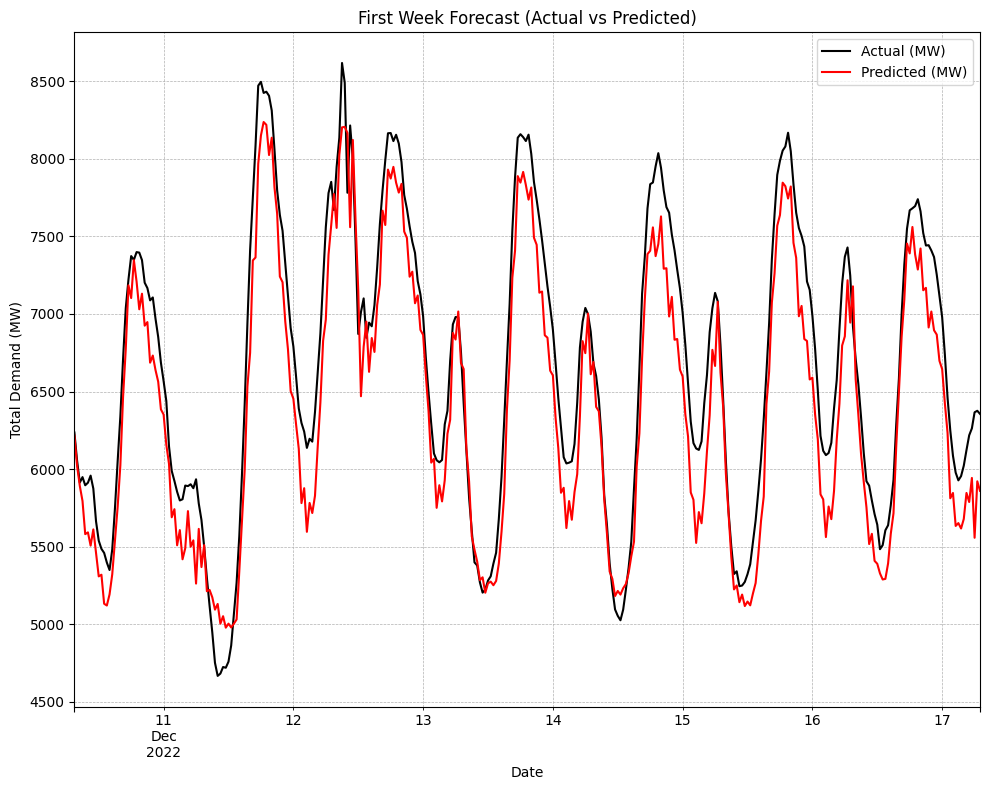

In [11]:
results = pd.DataFrame(index=y_test.index)
results["Actual (MW)"] = y_test
results["Predicted (MW)"] = y_pred_test

results.iloc[:336].plot(
    y=["Actual (MW)", "Predicted (MW)"],
    figsize=(10, 8),
    title="First Week Forecast (Actual vs Predicted)",
    color=["black", "red"],
)

plt.ylabel("Total Demand (MW)")
plt.xlabel("Date")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Model Interpretation (SHAP)

We use SHAP values to interpret the LightGBM residual model.
Since this model predicts residuals rather than total demand directly, SHAP importance reflects nonlinear corrections to the deterministic baseline.

In [12]:
X_sample = X2_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(model.model_2)
shap_values = explainer.shap_values(X_sample)

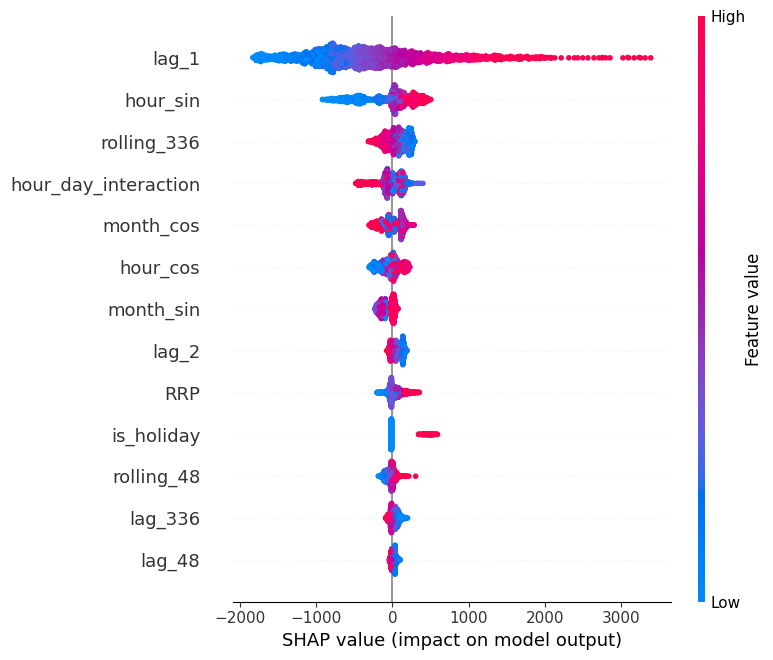

In [13]:
shap.summary_plot(shap_values, X_sample, plot_type="dot")

# Conclusion

* The Ridge + LightGBM hybrid reduced validation RMSE by ~13% versus baseline models.
* Weekly lag (t−336) and rolling features were critical for capturing medium-term structure.
* Ridge models deterministic trend and seasonality; LightGBM corrects short-term nonlinear volatility.
* SHAP confirms immediate lag and weekly rolling statistics dominate residual adjustments.
Test performance remained strong (R² ≈ 0.85), with minor degradation likely due to late-period market volatility.
Hybrid modeling proves both effective and interpretable for forecasting in volatile energy systems.
